# 04. Scale Experiment — D4v2 FAQ Architecture Experiment

**Цель**: определить критический размер KB, при котором retrieval-стратегии
начинают превосходить full context stuffing.

**Метод**: nested distractor expansion — добавляем нерелевантные (но правдоподобные)
медицинские тексты к базовой KB, сохраняя оригинальные факты.

**Размеры KB**: ~5K (базовая), ~15K, ~30K, ~50K токенов

**Стратегии**: S1-S4 (B0 не включается)

**Артефакты**: `outputs/scale_results.jsonl`, `outputs/figures/scale_curves.png`

In [1]:
%load_ext autoreload
%autoreload 2

import sys
sys.path.insert(0, '../..')

import os
from pathlib import Path

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from d4.config import load_config

sns.set_style('whitegrid')

OUTPUTS = Path('../outputs')
config = load_config('../configs/experiment.yaml')

## 1. Генерация расширенных KB

Nested distractor expansion: к базовой KB добавляются синтетические
чанки из смежных доменов (другие клиники, другие специализации),
чтобы увеличить размер контекста без изменения ground truth.

In [2]:
from d4.pipeline.chunker import load_chunks
from d4.data_gen.kb_scaler import build_scaled_kbs

# Базовая KB
base_chunks = load_chunks('../data/kb/chunks.json')
base_tokens = sum(c.token_count for c in base_chunks)
print(f'Базовая KB: {len(base_chunks)} chunks, {base_tokens} токенов')

# Целевые размеры (из секции kb_scale конфига)
scale_sizes = config.kb_scale.get('sizes_tokens', [5000, 15000, 30000, 50000])
print(f'Целевые размеры: {scale_sizes}')

# Генерация KB разных размеров через kb_scaler
scale_kbs = build_scaled_kbs(base_chunks, scale_sizes, seed=config.experiment.seed)

Базовая KB: 36 chunks, 6196 токенов
Целевые размеры: [5000, 15000, 30000, 50000]
KB   5000 tokens:   36 chunks, actual 6196 tokens
KB  15000 tokens:  186 chunks, actual 15008 tokens
KB  30000 tokens:  435 chunks, actual 30014 tokens
KB  50000 tokens:  768 chunks, actual 50029 tokens


In [3]:
# Distractor-логика вынесена в d4.data_gen.kb_scaler
# scale_kbs уже сгенерированы в ячейке выше
print(f'Сгенерировано {len(scale_kbs)} вариантов KB')
for size, chunks_list in sorted(scale_kbs.items()):
    actual = sum(c.token_count for c in chunks_list)
    print(f'  {size:>6d}: {len(chunks_list):>4d} chunks, {actual} tokens')

Сгенерировано 4 вариантов KB
    5000:   36 chunks, 6196 tokens
   15000:  186 chunks, 15008 tokens
   30000:  435 chunks, 30014 tokens
   50000:  768 chunks, 50029 tokens


## 2. Прогон стратегий на расширенных KB

In [4]:
from d4.pipeline.factory import build_strategies, build_llm_runner, precompute_embeddings
from d4.pipeline.orchestrator import Orchestrator
from d4.data_gen.query_generator import load_eval_set

# Eval set
eval_path = Path('../data/eval_set.yaml')
if not eval_path.exists():
    eval_path = Path('../data/eval_set_raw.yaml')
samples = load_eval_set(eval_path)

api_key = os.environ.get('OPENROUTER_API_KEY', '')
assert api_key, 'Установите OPENROUTER_API_KEY'

llm_runner = build_llm_runner(config, api_key)

print(f'Eval set: {len(samples)} запросов')
print(f'KB размеры: {list(scale_kbs.keys())}')
print(f'Стратегии: S1-S4 (без B0)')

Eval set: 90 запросов
KB размеры: [5000, 15000, 30000, 50000]
Стратегии: S1-S4 (без B0)


In [5]:
# Прогон по каждому размеру KB × стратегии
# ПРЕДУПРЕЖДЕНИЕ: долгий процесс, ~4 × 4 × N запросов
scale_results = {}  # {kb_size: list[StrategyResult]}

for kb_size, kb_chunks in scale_kbs.items():
    print(f'\n=== KB size: {kb_size} tokens ({len(kb_chunks)} chunks) ===')
    
    # Стратегии из factory (без B0 для scale experiment)
    strategies = build_strategies(config, include_baseline=False)
    precompute_embeddings(strategies, kb_chunks)
    
    output_path = OUTPUTS / f'scale_results_{kb_size}.jsonl'
    orch = Orchestrator(
        strategies=strategies,
        llm_runner=llm_runner,
        chunks=kb_chunks,
        checkpoint_every=config.rate_limit.checkpoint_every_n,
        max_workers=config.rate_limit.max_workers,
        output_path=output_path,
    )
    
    existing = Orchestrator.load_results(output_path)
    resume_keys = Orchestrator.get_completed_keys(existing)
    
    results = orch.run_all(samples, resume_from=resume_keys)
    scale_results[kb_size] = existing + results
    print(f'  Результатов: {len(scale_results[kb_size])}')


=== KB size: 5000 tokens (36 chunks) ===


huggingface/tokenizers: The current process just got forked, after parallelism has already been used. Disabling parallelism to avoid deadlocks...
To disable this warning, you can either:
	- Avoid using `tokenizers` before the fork if possible
	- Explicitly set the environment variable TOKENIZERS_PARALLELISM=(true | false)


  запуск: 360 задач, 8 потоков
  checkpoint: 25/360 (2.2 req/s, ETA 154s)
  checkpoint: 50/360 (2.4 req/s, ETA 130s)
  checkpoint: 75/360 (2.4 req/s, ETA 120s)
  checkpoint: 100/360 (2.4 req/s, ETA 110s)
  checkpoint: 125/360 (2.3 req/s, ETA 103s)
  checkpoint: 150/360 (2.2 req/s, ETA 94s)
  checkpoint: 175/360 (2.2 req/s, ETA 83s)
  checkpoint: 200/360 (2.3 req/s, ETA 71s)
  checkpoint: 225/360 (2.3 req/s, ETA 58s)
  checkpoint: 250/360 (2.3 req/s, ETA 47s)
  checkpoint: 275/360 (2.4 req/s, ETA 36s)
  checkpoint: 300/360 (2.4 req/s, ETA 25s)
  checkpoint: 325/360 (2.4 req/s, ETA 15s)
  checkpoint: 350/360 (2.4 req/s, ETA 4s)
Готово: 360/360 за 148.6s
  Результатов: 360

=== KB size: 15000 tokens (186 chunks) ===
  запуск: 360 задач, 8 потоков
  checkpoint: 25/360 (2.5 req/s, ETA 136s)
  checkpoint: 50/360 (2.4 req/s, ETA 130s)
  checkpoint: 75/360 (2.4 req/s, ETA 120s)
  checkpoint: 100/360 (2.4 req/s, ETA 108s)
  checkpoint: 125/360 (2.4 req/s, ETA 99s)
  checkpoint: 150/360 (2.3 req

## 3. Анализ: кривые масштабирования

In [6]:
from d4.evaluation.deterministic import evaluate_batch
from d4.evaluation.metrics import aggregate_deterministic, aggregate_system_metrics

scale_metrics = []  # [{kb_size, strategy, metric, value}]

for kb_size, kb_results in scale_results.items():
    kb_chunks = scale_kbs[kb_size]
    
    # Deterministic
    det = evaluate_batch(kb_results, samples, kb_chunks)
    det_agg = aggregate_deterministic(det)
    
    # System
    sys_agg = aggregate_system_metrics(kb_results)
    
    for sid in det_agg:
        scale_metrics.append({
            'kb_size': kb_size,
            'strategy': sid,
            'answerability_accuracy': det_agg[sid]['answerability_accuracy'],
            'unsupported_claim_rate': det_agg[sid]['unsupported_claim_rate'],
            'latency_p50': sys_agg.get(sid, {}).get('latency_p50', 0),
            'mean_context_length': sys_agg.get(sid, {}).get('mean_context_length', 0),
        })

df_scale = pd.DataFrame(scale_metrics)
print(df_scale.pivot_table(values='answerability_accuracy', index='kb_size', columns='strategy').round(3))

strategy     S1     S2     S3     S4
kb_size                             
5000      0.889  0.789  0.856  0.822
15000     0.911  0.811  0.778  0.822
30000     0.900  0.789  0.778  0.833
50000     0.889  0.800  0.778  0.844


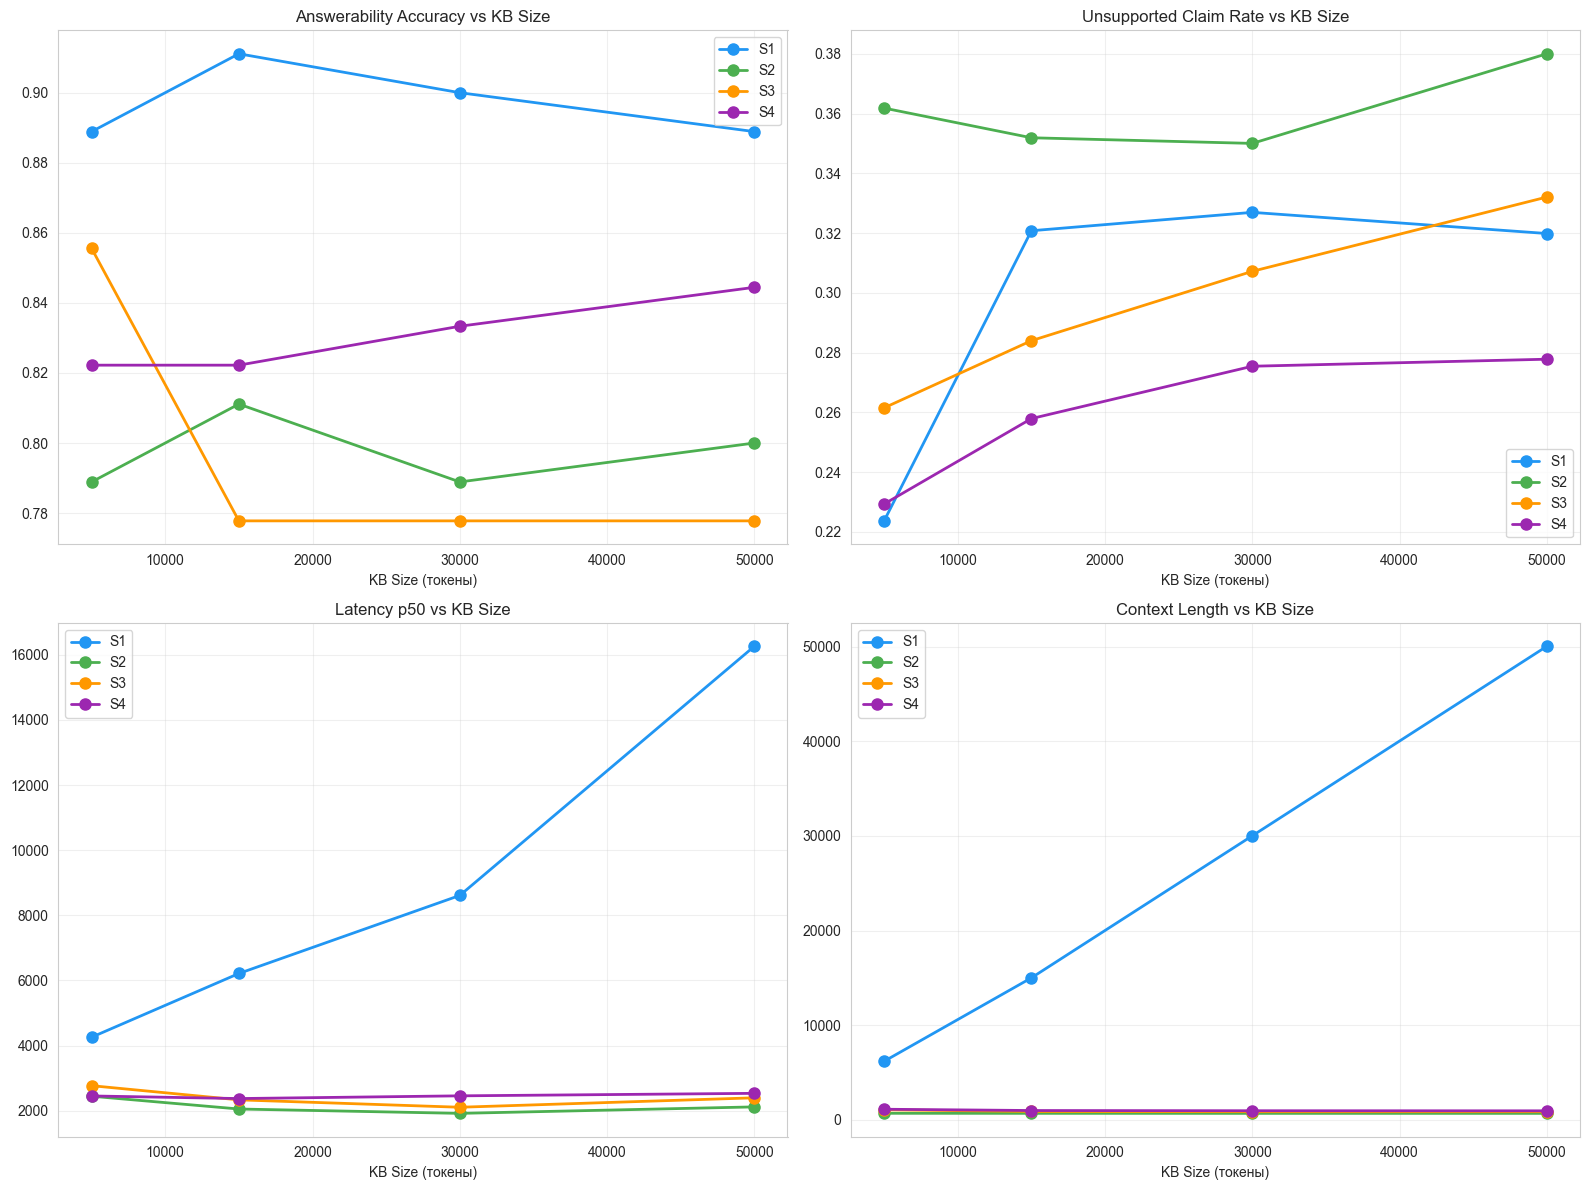

In [7]:
# Кривые масштабирования
fig, axes = plt.subplots(2, 2, figsize=(16, 12))

strategy_colors = {'S1': '#2196F3', 'S2': '#4CAF50', 'S3': '#FF9800', 'S4': '#9C27B0'}

for metric, ax, title in [
    ('answerability_accuracy', axes[0, 0], 'Answerability Accuracy vs KB Size'),
    ('unsupported_claim_rate', axes[0, 1], 'Unsupported Claim Rate vs KB Size'),
    ('latency_p50', axes[1, 0], 'Latency p50 vs KB Size'),
    ('mean_context_length', axes[1, 1], 'Context Length vs KB Size'),
]:
    for sid in ['S1', 'S2', 'S3', 'S4']:
        mask = df_scale['strategy'] == sid
        data = df_scale[mask].sort_values('kb_size')
        ax.plot(data['kb_size'], data[metric], 'o-', 
                color=strategy_colors[sid], label=sid, linewidth=2, markersize=8)
    ax.set_xlabel('KB Size (токены)')
    ax.set_title(title)
    ax.legend()
    ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig(OUTPUTS / 'figures' / 'scale_curves.png', dpi=150, bbox_inches='tight')
plt.show()

## 4. Определение точки перехода (crossover)

In [8]:
# Точка перехода: где S2/S3/S4 начинают превосходить S1
pivot = df_scale.pivot_table(
    values='answerability_accuracy', 
    index='kb_size', 
    columns='strategy',
)

print('Accuracy по размерам KB:')
print(pivot.round(3))
print()

# Где retrieval > full context?
for sid in ['S2', 'S3', 'S4']:
    if sid in pivot.columns and 'S1' in pivot.columns:
        diff = pivot[sid] - pivot['S1']
        crossover = diff[diff > 0].index
        if len(crossover) > 0:
            print(f'{sid} > S1 начиная с {crossover[0]} токенов')
        else:
            print(f'{sid}: не превосходит S1 ни при каком размере KB')

Accuracy по размерам KB:
strategy     S1     S2     S3     S4
kb_size                             
5000      0.889  0.789  0.856  0.822
15000     0.911  0.811  0.778  0.822
30000     0.900  0.789  0.778  0.833
50000     0.889  0.800  0.778  0.844

S2: не превосходит S1 ни при каком размере KB
S3: не превосходит S1 ни при каком размере KB
S4: не превосходит S1 ни при каком размере KB


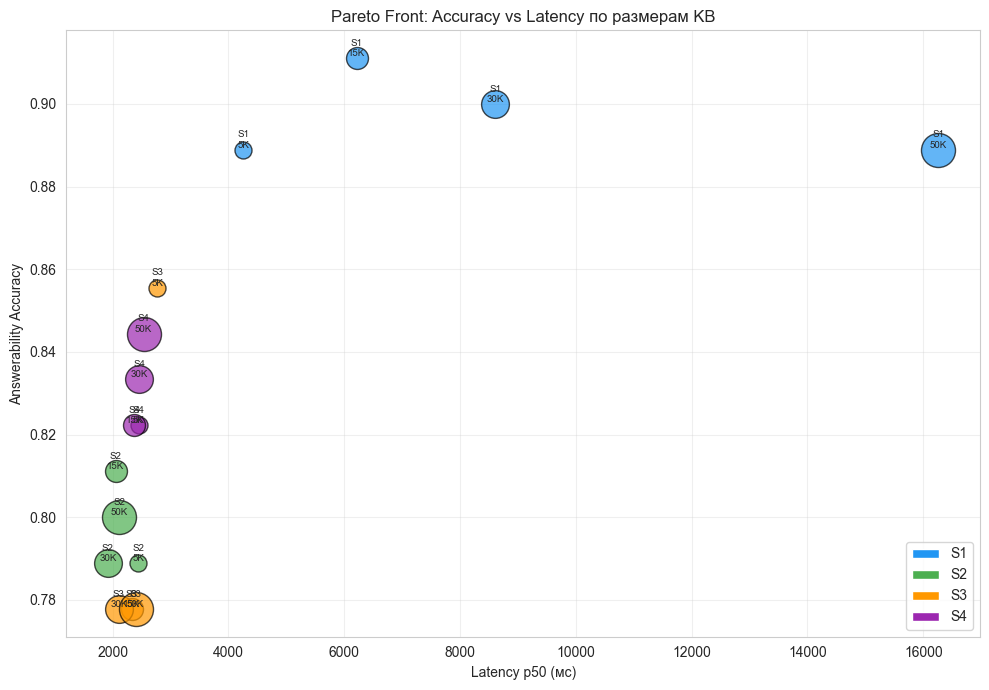

ERROR:tornado.general:Uncaught exception in ZMQStream callback
Traceback (most recent call last):
  File "/opt/anaconda3/envs/ml-python312/lib/python3.12/site-packages/zmq/eventloop/zmqstream.py", line 565, in _log_error
    f.result()
  File "/opt/anaconda3/envs/ml-python312/lib/python3.12/site-packages/ipykernel/kernelbase.py", line 302, in dispatch_control
    await self.process_control(msg)
  File "/opt/anaconda3/envs/ml-python312/lib/python3.12/site-packages/ipykernel/kernelbase.py", line 308, in process_control
    idents, msg = self.session.feed_identities(msg, copy=False)
                  ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/opt/anaconda3/envs/ml-python312/lib/python3.12/site-packages/jupyter_client/session.py", line 994, in feed_identities
    raise ValueError(msg)
ValueError: DELIM not in msg_list
ERROR:tornado.general:Uncaught exception in ZMQStream callback
Traceback (most recent call last):
  File "/opt/anaconda3/envs/ml-python312/lib/python3.12/site-pac

In [9]:
# Pareto front: accuracy vs latency
fig, ax = plt.subplots(figsize=(10, 7))

for kb_size in sorted(scale_kbs.keys()):
    mask = df_scale['kb_size'] == kb_size
    data = df_scale[mask]
    for _, row in data.iterrows():
        ax.scatter(
            row['latency_p50'], row['answerability_accuracy'],
            c=strategy_colors.get(row['strategy'], 'gray'),
            s=100 + kb_size / 100,
            alpha=0.7,
            edgecolor='black',
        )
        ax.annotate(
            f"{row['strategy']}\n{kb_size//1000}K",
            (row['latency_p50'], row['answerability_accuracy']),
            fontsize=7, ha='center', va='bottom',
        )

ax.set_xlabel('Latency p50 (мс)')
ax.set_ylabel('Answerability Accuracy')
ax.set_title('Pareto Front: Accuracy vs Latency по размерам KB')
ax.grid(True, alpha=0.3)

# Легенда
from matplotlib.patches import Patch
legend_elements = [Patch(facecolor=c, label=s) for s, c in strategy_colors.items()]
ax.legend(handles=legend_elements, loc='lower right')

plt.tight_layout()
plt.savefig(OUTPUTS / 'figures' / 'pareto_accuracy_latency.png', dpi=150, bbox_inches='tight')
plt.show()